<a href="https://colab.research.google.com/github/cindy-purity/Data-Analysis/blob/main/merged_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**In this analysis we are aiming for the following questions to be answered;**

1. Which department has the highest average salary?
2. Show only employees who joined after 2020 and earn more than 60,000.
3. Sort the entire dataset by age from youngest to oldest.






In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load and explore the data
df = pd.read_csv('/content/merged_result.csv')
display(df.head())

,name,dept,salary,budget_kes,age,year_joined
0,James Mwenda,Engineering,"KES 56,000","5,000,000",28,2021
1,Fatuma Said,Marketing,"KES 92,500","3,500,000",31,2019
2,Peter Limo,Engineering,"KES 71,760","5,000,000",30,2020
3,Unknown,Finance,"KES 78,000","4,200,000",35,2022
4,Grace Achieng,Marketing,"KES 61,200","3,500,000",29,2023


In [ ]:
#Clean and validate data
df.info()
print("\nMissing values per column:")
display(df.isna().sum())
print("\nNumber of duplicate rows:")
display(df.duplicated().sum())
df['salary'] = (df['salary']
                .str.replace(',', '')
                .str.replace('KES', '')
                .astype(float)
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   name         6 non-null      object
 1   dept         6 non-null      object
 2   salary       6 non-null      object
 3   budget_kes   6 non-null      object
 4   age          6 non-null      int64 
 5   year_joined  6 non-null      int64 
dtypes: int64(2), object(4)
memory usage: 420.0+ bytes

Missing values per column:


,0
name,0
dept,0
salary,0
budget_kes,0
age,0
year_joined,0



Number of duplicate rows:


np.int64(0)

In [ ]:
# Which department has the highest average salary?
top_dept = df.groupby('dept')['salary'].mean().sort_values(ascending=False).round(0).index[0]
print(f'The department with the highest average salary is {top_dept}')

The department with the highest average salary is Finance


In [ ]:
# Show only employees who joined after 2020 and earn more than 60,000.
filtered_data = df[(df['year_joined'] > 2020) & (df['salary'] > 60000)]
display(filtered_data)

,name,dept,salary,budget_kes,age,year_joined
3,Unknown,Finance,78000.0,"4,200,000",35,2022
4,Grace Achieng,Marketing,61200.0,"3,500,000",29,2023


In [ ]:
#Sort the entire dataset by age from youngest to oldest.
df = df.sort_values(by = 'age', ascending = True)
display(df)

,name,dept,salary,budget_kes,age,year_joined
0,James Mwenda,Engineering,56000.0,"5,000,000",28,2021
4,Grace Achieng,Marketing,61200.0,"3,500,000",29,2023
2,Peter Limo,Engineering,71760.0,"5,000,000",30,2020
1,Fatuma Said,Marketing,92500.0,"3,500,000",31,2019
3,Unknown,Finance,78000.0,"4,200,000",35,2022
5,Hassan Yusuf,Finance,84500.0,"4,200,000",41,2018


**Data Visualisation**
1. A bar chart showing average salary by department, sorted highest to lowest.

2. A scatter plot showing age on the x-axis and salary on the y-axis, with dots coloured by department.

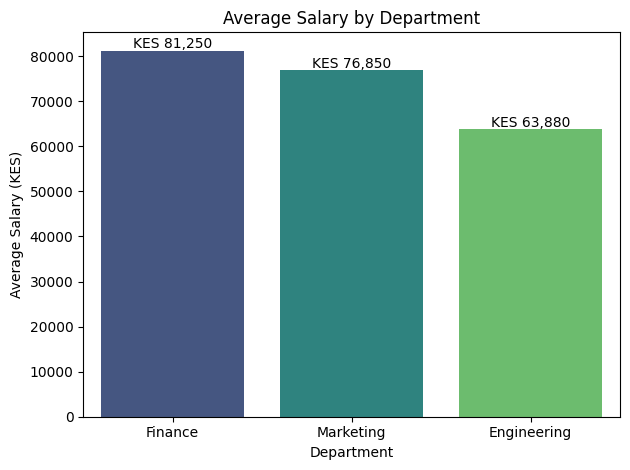

In [ ]:
# Average Salary by Department

avg_salary_by_dept = df.groupby('dept')['salary'].mean().sort_values(ascending = False)
sns.barplot(x = avg_salary_by_dept.index, y = avg_salary_by_dept.values, hue=avg_salary_by_dept.index, palette='viridis', legend=False)
for i, value in enumerate(avg_salary_by_dept.values):
    plt.text(i, value + 500, f'KES {int(value):,}', ha='center', fontsize=10)
plt.xlabel('Department')
plt.ylabel('Average Salary (KES)')
plt.title('Average Salary by Department')
plt.tight_layout()
plt.show()

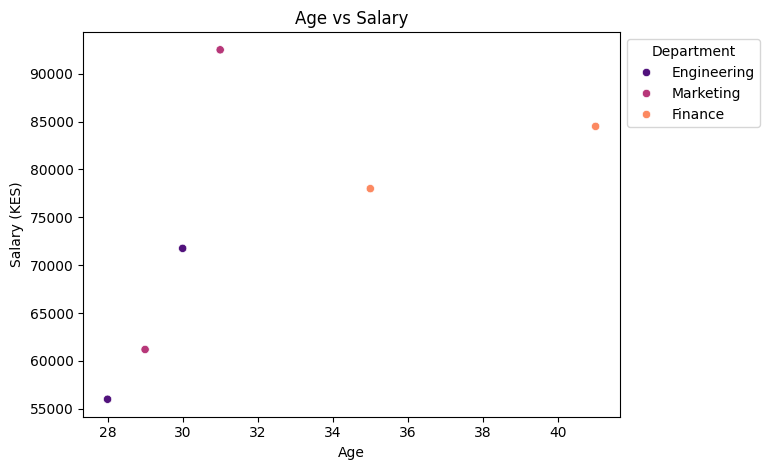

In [ ]:
#Comparison beetween age and salary
sns.scatterplot(data=df, x='age', y='salary', hue = 'dept', palette = 'magma')
plt.xlabel('Age')
plt.ylabel('Salary (KES)')
plt.title('Age vs Salary')
plt.tight_layout()
plt.legend(title='Department', bbox_to_anchor=(1, 1))
plt.show()

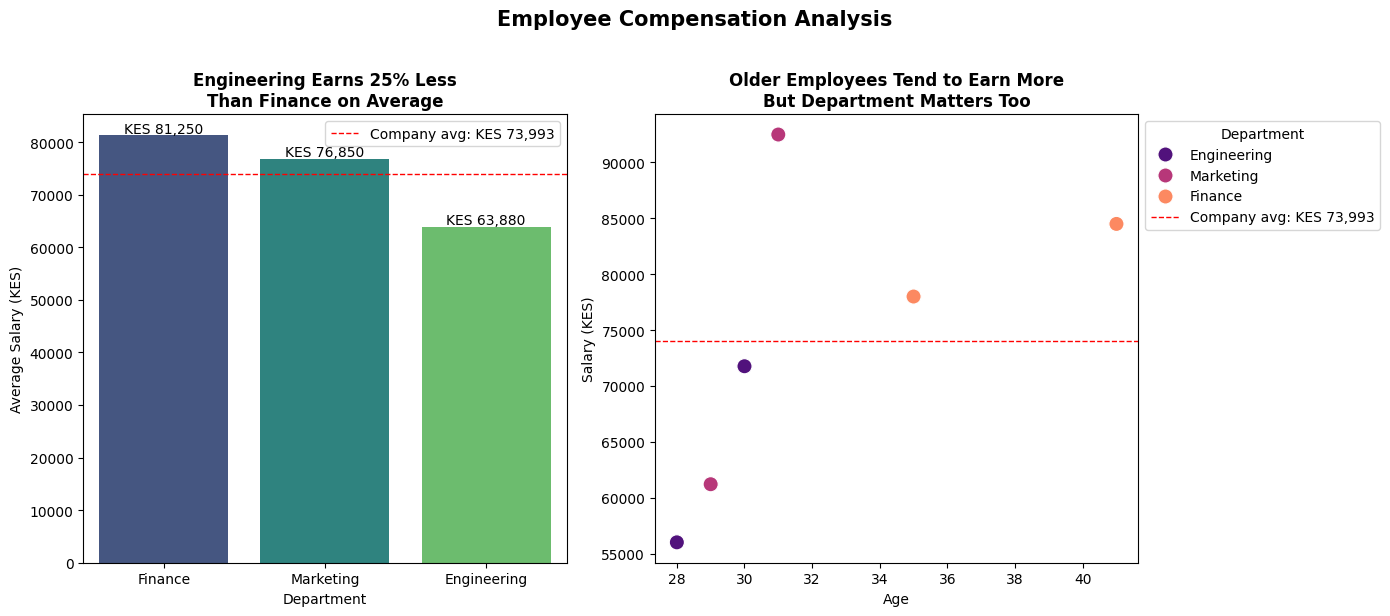

In [ ]:


company_avg = df['salary'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Employee Compensation Analysis', fontsize=15, fontweight='bold', y=1.02)

avg_salary_by_dept = df.groupby('dept')['salary'].mean().sort_values(ascending=False).round(0)

sns.barplot(x=avg_salary_by_dept.index, y=avg_salary_by_dept.values,
            hue=avg_salary_by_dept.index, palette='viridis',
            legend=False, ax=axes[0])

axes[0].axhline(y=company_avg, color='red', linestyle='--', linewidth=1,
                label=f'Company avg: KES {int(company_avg):,}')

for i, value in enumerate(avg_salary_by_dept.values):
    axes[0].text(i, value + 500, f'KES {int(value):,}', ha='center', fontsize=10)

axes[0].set_title('Engineering Earns 25% Less\nThan Finance on Average', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Average Salary (KES)')
axes[0].legend()

sns.scatterplot(data=df, x='age', y='salary', hue='dept',
                palette='magma', s=120, ax=axes[1])

axes[1].axhline(y=company_avg, color='red', linestyle='--', linewidth=1,
                label=f'Company avg: KES {int(company_avg):,}')

axes[1].set_title('Older Employees Tend to Earn More\nBut Department Matters Too', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Salary (KES)')
axes[1].legend(title='Department', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

**Statistics**

 Engineering earns less than Finance. But with only 2 engineers and 2 finance staff, could that just be coincidence?

In [ ]:
from scipy import stats

eng = df[df['dept']=='Engineering']['salary']
fin = df[df['dept']=='Finance']['salary']

# Two-sample t-test
t_stat, p_value = stats.ttest_ind(eng, fin)

print(f't-statistic: {t_stat:.3f}')
print(f'p-value: {p_value:.3f}')

if p_value < 0.05:
    print('Difference is statistically significant')
else:
    print('Difference could be due to chance')

t-statistic: -2.038
p-value: 0.178
Difference could be due to chance


In [ ]:
from scipy import stats
import numpy as np

salaries = df['salary']

print("=== Distribution Summary ===")
print(f"Mean:   KES {salaries.mean():,.0f}")
print(f"Median: KES {salaries.median():,.0f}")
print(f"Std Dev: KES {salaries.std():,.0f}")
print(f"Skewness: {salaries.skew():.2f}")
print()

print("=== Parameter Estimation ===")
se = stats.sem(salaries)
print(f"Standard Error: KES {se:,.0f}")
print()

print("=== 95% Confidence Interval ===")
ci = stats.t.interval(
    confidence=0.95,
    df=len(salaries)-1,
    loc=salaries.mean(),
    scale=se
)
print(f"We are 95% confident the true mean salary is between")
print(f"KES {ci[0]:,.0f} and KES {ci[1]:,.0f}")
print()

print("=== Hypothesis Test: Engineering vs Finance ===")
eng = df[df['dept'] == 'Engineering']['salary']
fin = df[df['dept'] == 'Finance']['salary']

t_stat, p_value = stats.ttest_ind(eng, fin)
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.3f}")
print()

if p_value < 0.05:
    print("Verdict: The salary difference is statistically significant.")
else:
    print("Verdict: Cannot confirm the difference is real with this sample size.")
    print("We need more data before making a business decision.")

=== Distribution Summary ===
Mean:   KES 73,993
Median: KES 74,880
Std Dev: KES 13,866
Skewness: -0.04

=== Parameter Estimation ===
Standard Error: KES 5,661

=== 95% Confidence Interval ===
We are 95% confident the true mean salary is between
KES 59,442 and KES 88,545

=== Hypothesis Test: Engineering vs Finance ===
t-statistic: -2.038
p-value: 0.178

Verdict: Cannot confirm the difference is real with this sample size.
We need more data before making a business decision.
